# CoCo Project 2025

## ReadMe

### Model-Based Controller

#### Implementation MPC

- The setup is split in 2 parts as proposed
- The `MPC_Controller` processes only it's core function
- The `MPC_ControlSim` handles the I/O and works as basic estimator and target selector

##### Controller

Takes as input the current state in delta-form, the steady state and input and it returns the output in delta-form.

It has its own CVX objects with the constraints and objective set at the beginning. During the process, it updates the parameters but never changes the form.

It is designed modular and can easily be modified and adapted.

##### ControlSim

Estimates the current state from the given values. Summarizes the disturbances and generates the steady state with its own optimizer. From that it shifts the state and input to an optimal value at zero for the controller.

After generating the desired states with the estimator (basic implementation) and the target selector, it handles this values to the controller and takes back the new input which is handed over to the main simulation.

#### Parameter

Main Tuning Parameter $Q, R, S$ for the calculation of the cost to optimize and $K$ for the horizon.

- $Q$ used the approach $1/(\rho^\star)^2$ for all $\rho^\star_i$
- $R$ stay at $I$ provided the best results
- $S$ was tested intensively, values around 500 showed the best results
- $K$ possible from 20-30 up to 80 worked in some demonstrations, 60 worked best

For the $Q$ and $R$ i would stay with the basic approximations. $S$ can have a strong influence and needs to be checked under any possible circumstances. For $K$ i would stay at 60 and test new values when there are changes at the model or the system.


### Data-driven (NOT IMPLEMENTED...)
  - How the proposed controller is implemented.
  - What **parameters need to be tuned**
  - How you tuned and how you would recommend tuning the parameters

## Preparation

In [4]:
%env SUMO_HOME=/usr/share/sumo 

env: SUMO_HOME=/usr/share/sumo


In [30]:
from typing import Union, override
import cvxpy as cvx
import matplotlib.pyplot as plt
import numpy as np
import json

from src.controllers import controller
from src.tasks import dsl
from src.tasks.estimate import Estimate
from src.simulations.testcontrolsim import test_ControlSim
from src.tasks.dsl import DSL
from src.controllers.controller import Controller
from src.simulations.controlsim import ControlSim

# from src.visualization.visualization import *
from src.data.comparison import Comparison
from src.data.experiment import Experiment

### Utils

In [16]:
np.set_printoptions(precision=3)

In [29]:
taskparams_json = "dep/sumo_files/cocoCity/simparams/cocoCity.json"
with open(taskparams_json, "r") as file:
    taskparams = json.load(file)
mfd_taskparams = "dep/sumo_files/cocoCity/simparams/cocoCity_mfd.json"
with open(mfd_taskparams, "r") as file:
    mfd_taskparams = json.load(file)

def get_system_params():
    """
    Linearizes model as given
    """
    dsl_task = DSL(taskparams, test_ControlSim)
    rho_star = np.array([5.70, 9.83, 10.63, 14.55, 11.94])
    v_target = np.ones(5)
    sim_period = 20  # sampling time (fixed)
    model = dsl_task.simulation.get_model()
    A, B, C, d = model.linearize(sim_period, rho_star, v_target)
    return (A, B, C, d)

## Model Predictive Controller

In [17]:
class MPC_Controller(Controller):
    def __init__(self, actuators, params={}) -> None:
        """Initialize the controller"""
        super().__init__(actuators=actuators, params=params)
        self.name = "MPC"
        # ---
        self.output_path = "./test"
        ### system specific params
        # state space model
        self.A: np.ndarray
        self.B: np.ndarray
        self.C: np.ndarray
        # linearization offset
        self.d: np.ndarray
        # dimenstions
        self.nx: int
        self.nu: int
        # cost parameter
        self.Q: np.ndarray
        self.R: np.ndarray
        # cost on final state
        self.S: np.ndarray
        ### task specific params
        # initial condition, gets updated in simulation
        # self.x_t: np.ndarray
        # prediciton horizon, is fix
        self.T: int
        # control horizon
        self.K: int
        # check, transform and set params
        self._set_system(params)
        ### optimization problem
        self.variables = self._get_variables()
        self.cvx_parameters = self._get_cvx_parameters()
        constraints = self._get_constraints()
        objective = self._get_objective()
        self.problem = cvx.Problem(objective, constraints)
        print("MPC controller initialized")
        # placeholder for storing information
        self.summed_cost: float = 0
        self.x_trajectory: np.ndarray
        self.u_trajectory: np.ndarray

    def _set_system(self, p):
        """
        Sets up values from system and params
        """
        # system parameter
        A, B, C, d = get_system_params()
        self.A = np.atleast_2d(A)
        n_h, n_w = self.A.shape
        self.nx = n_w
        self.B = np.atleast_2d(B)
        n_h_check, p_w = self.B.shape
        self.nu = p_w
        self.C = np.atleast_2d(C)
        self.d = np.atleast_2d(d)
        # cost parameter
        self.Q = np.atleast_2d(np.array(p["Q"]))
        self.R = np.atleast_2d(np.array(p["R"]))
        self.S = np.atleast_2d(np.array(p["S"]))
        # horizon params
        self.T = p["T"]
        self.K = p["K"]
        # target state

    def _get_variables(self) -> dict:
        """
        Define and store optimization variables
        """
        variables = {
            "X": cvx.Variable((self.nx, self.K + 1)),
            "U": cvx.Variable((self.nu, self.K)),
        }
        return variables

    def _get_cvx_parameters(self) -> dict:
        """
        Define mutable problem parameters
        """
        problem_parameters = {
            "X_t": cvx.Parameter(self.nx),
            "X_s": cvx.Parameter(self.nx),
            "U_s": cvx.Parameter(self.nu),
        }

        return problem_parameters

    def _get_constraints(self) -> list[cvx.Constraint]:
        """
        Define cvx constraints from dynamics and system
        """
        # X,U time series
        X = self.variables["X"]
        U = self.variables["U"]
        # initial x and disturbance for 1 iteration
        X_t = self.cvx_parameters["X_t"]
        # steady state prediction for 1 iteration
        X_s = self.cvx_parameters["X_s"]
        U_s = self.cvx_parameters["U_s"]

        A, B = self.A, self.B
        # constraint for first state
        constraints = [X[:, 0] == X_t]
        for k in range(self.K):
            constraints += [
                # dynamic constraints
                X[:, k + 1] == A @ X[:, k] + B @ U[:, k],
                # state constraints
                # TODO: restrict maximal state?
                # input constraints
                U[:, k] <= 1.5 * np.ones(self.nu) - U_s,
                U[:, k] >= U_s - 0.5 * np.ones(self.nu),
            ]
        # final state constraint
        # constraints += [X[:, self.K] == 0]
        # --> use high penalty in cost function to ensure solution

        return constraints

    def _get_objective(self) -> Union[cvx.Minimize, cvx.Maximize]:
        """
        Define objective, high cost on final state
        """
        X = self.variables["X"]
        U = self.variables["U"]
        objective = 0
        for k in range(self.K):
            objective += cvx.quad_form(X[:, k], self.Q)
            objective += cvx.quad_form(U[:, k], self.R)
        objective += cvx.quad_form(X[:, -1], self.S)
        return cvx.Minimize(objective)

    def solve_problem(self):
        """
        Updates parameter, runs solver and checks result
        """
        # try to solve
        self.problem.solve(verbose=False)
        # solver=cvx.MOSEK, verbose=False
        # check solver status
        for key, variable in self.variables.items():
            if variable.value is None:
                print(f"Solver failed: {key}.value is None")
                # raise ValueError(f"Solver failed: {key}.value is None")

    def get_u_delta(self, x_t, x_s, u_s):
        """
        Calls solver, takes first input or 0, predicts next state
        """
        self.cvx_parameters["X_t"].value = x_t
        self.cvx_parameters["X_s"].value = x_s
        self.cvx_parameters["U_s"].value = u_s

        self.solve_problem()
        # get input
        if self.variables["U"].value is not None:
            u_delta = self.variables["U"].value[:, 0]
        else:
            u_delta = np.zeros(self.nx)
            print("u_delta was not calculated correctly!")
        return u_delta

    def get_next_input(self, *args):
        """
        Requisite from Controller class, override caused problems
        """
        return super().get_next_input(*args)


## MPC Control Simulation

In [18]:
class MPC_ControlSim(ControlSim):
    def __init__(self, network, taskparams, actuators, controlparams={}):
        super().__init__(
            network=network,
            taskparams=taskparams,
            actuators=actuators,
            controlparams=controlparams,
        )
        self.output_path = "out/mpc/test_X"
        # steady state and input
        self.X_s: cvx.Variable
        self.U_s: cvx.Variable
        # disturbance (summary of C @ q + d), mutable
        self.D_t: cvx.Parameter
        # optimal value, designed mutable for later implementations
        self.Rho: cvx.Parameter
        self.problem: cvx.Problem
        print("MPC control simulation initialized")

    def compute_input(  self, k, forecast, controller, controller_name, uAppliedMatrix, yMeasuredMatrix, ySingleStepPredMatrix, m, p, r, u_min, u_max,): # type: ignore
        ### inputs 
        # "k" # iteration step, k in range (180)
        # "forecast" forecast of traffic, only current state used
        # "controller" controller that is implemented above
        # "controller_name" controller_name
        # "uAppliedMatrix"  # u that is sent from here
        # "yMeasuredMatrix"  # measured y, filling  up
        # "ySingleStepPredMatrix": ySingleStepPredMatrix,  # y that this function sends
        # "m": m,  # ??? always same, 5
        # "p": p, # ??? always same, 5
        # "r": r,  # rho star, always same
        # "u_min": u_min, # always same, 0.5
        # "u_max": u_max, # always same, 1.5

        # setup OP, not possible in __init__
        if k == 0:
            self.setup_steady_state_OP()

        # extract current state
        x = yMeasuredMatrix[:, k]  # TODO: estimator
        # calculate disturbance
        q = forecast[k, :]
        disturbance = controller.C @ q + controller.d
        # prepare (steady) state for delta zero system
        x_delta, x_s, u_s = self.target_selector(x, r, disturbance)
        # get input for delta zero system
        u_delta = controller.get_u_delta(x_delta, x_s, u_s)
        u = u_delta + u_s
        # apply dynamics to get next state
        y = self.predict_next_state(x, u, disturbance)

        return u, y

    def predict_next_state(self, x, u, d):
        """
        Applies dynamics
        """
        A = self.controller.A
        B = self.controller.B
        x_next = A @ x + B @ u + d

        return x_next

    def target_selector(self, x, r, disturbance):
        """
        Calculates steady state and delta x
        """
        self.D_t.value = disturbance.reshape(-1)
        self.Rho.value = r
        self.problem.solve(solver="SCS")  # MOSEK no license...
        x_s = self.X_s.value
        # x_s = X_s if X_s is not None else r #TODO: failsave
        u_s = self.U_s.value
        x_delta = x - x_s
        return x_delta, x_s, u_s

    def setup_steady_state_OP(self):
        """
        Initialization of steady state optimization problem
        """
        nx, nu = self.controller.nx, self.controller.nu
        X_s = cvx.Variable(nx)
        U_s = cvx.Variable(nu)
        D_t = cvx.Parameter(nx)
        Rho = cvx.Parameter(nx)
        A = self.controller.A
        B = self.controller.B
        constraints = [
            X_s == A @ X_s + B @ U_s + D_t,
            U_s <= 1.5 * np.ones(self.controller.nu),
            U_s >= 0.5 * np.ones(self.controller.nu),
        ]
        objective = cvx.Minimize(cvx.norm(X_s - Rho))
        # TODO: test nu star to push input higher
        problem = cvx.Problem(objective, constraints)
        # finally set all states
        self.X_s = X_s
        self.U_s = U_s
        self.D_t = D_t
        self.Rho = Rho
        self.problem = problem


## Run Controller and  Simulation

In [19]:
rho_star = [5.70, 9.83, 10.63, 14.55, 11.94]

q_star = [1 / q**2 for q in rho_star]

### use this to compare multiple results
# for s in [470, 500, 600]:
#     for k in [60, 62]:

for s in [500]:
    for k in [60]:
        task_name = f"q_star_final_S_{s}_K_{k}"
        output_path = f"out/mpc/{task_name}/"
        print()
        print(f"Run MPC: {task_name}")
        print()
        param = {
            "Q": np.diag(q_star),
            "R": np.eye(5),
            "S": np.diag([1, 1, 1, 1, s]),
            "T": 180,
            "K": k,
        }

        dsl_task = DSL(taskparams, MPC_ControlSim)
        dsl_task.simulation.output_path = output_path
        experiment = dsl_task.runtask(
            init_from_notebook=True,
            controller_class=MPC_Controller,
            controller_json=param,
        )


Run MPC: q_star_final_S_500_K_60

MPC control simulation initialized
Running Simulation...
 Retrying in 1 seconds


MPC controller initialized


/home/silvan/Coding/coco-project-2025/.venv/lib/python3.13/site-packages/traci/main.py:200: UserWarning: API change now handles step as floating point seconds
  connection.check().simulationStep(step)


Step #3580.00 (0ms ?*RT. ?UPS, TraCI: 19ms, vehicles TOT 1703 ACT 45 BUF 0)               
Simulation successful
Saving experiment results to out/mpc/q_star_final_S_500_K_60/. This directory can be copied and renamed if you want to retain the results, otherwise it will be overwritten during the next experiment!


### Plot last experiment

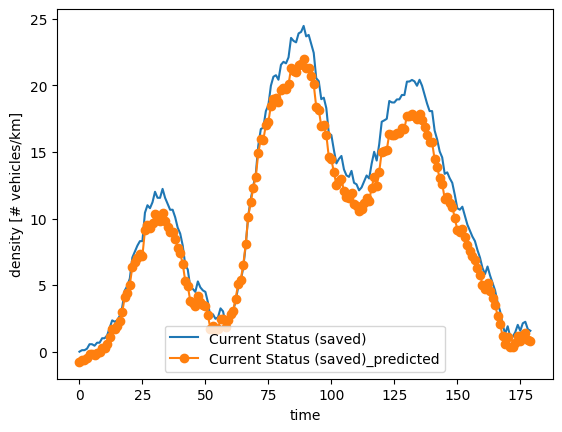

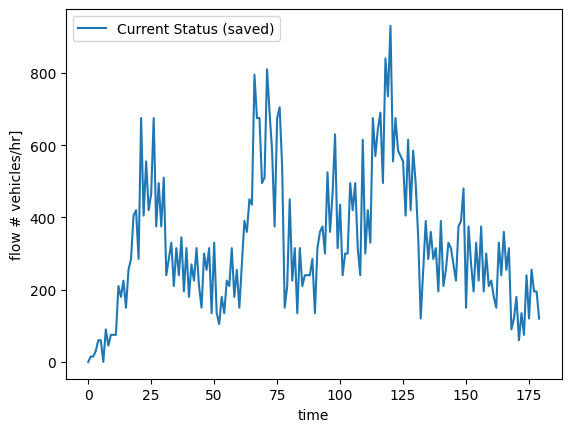

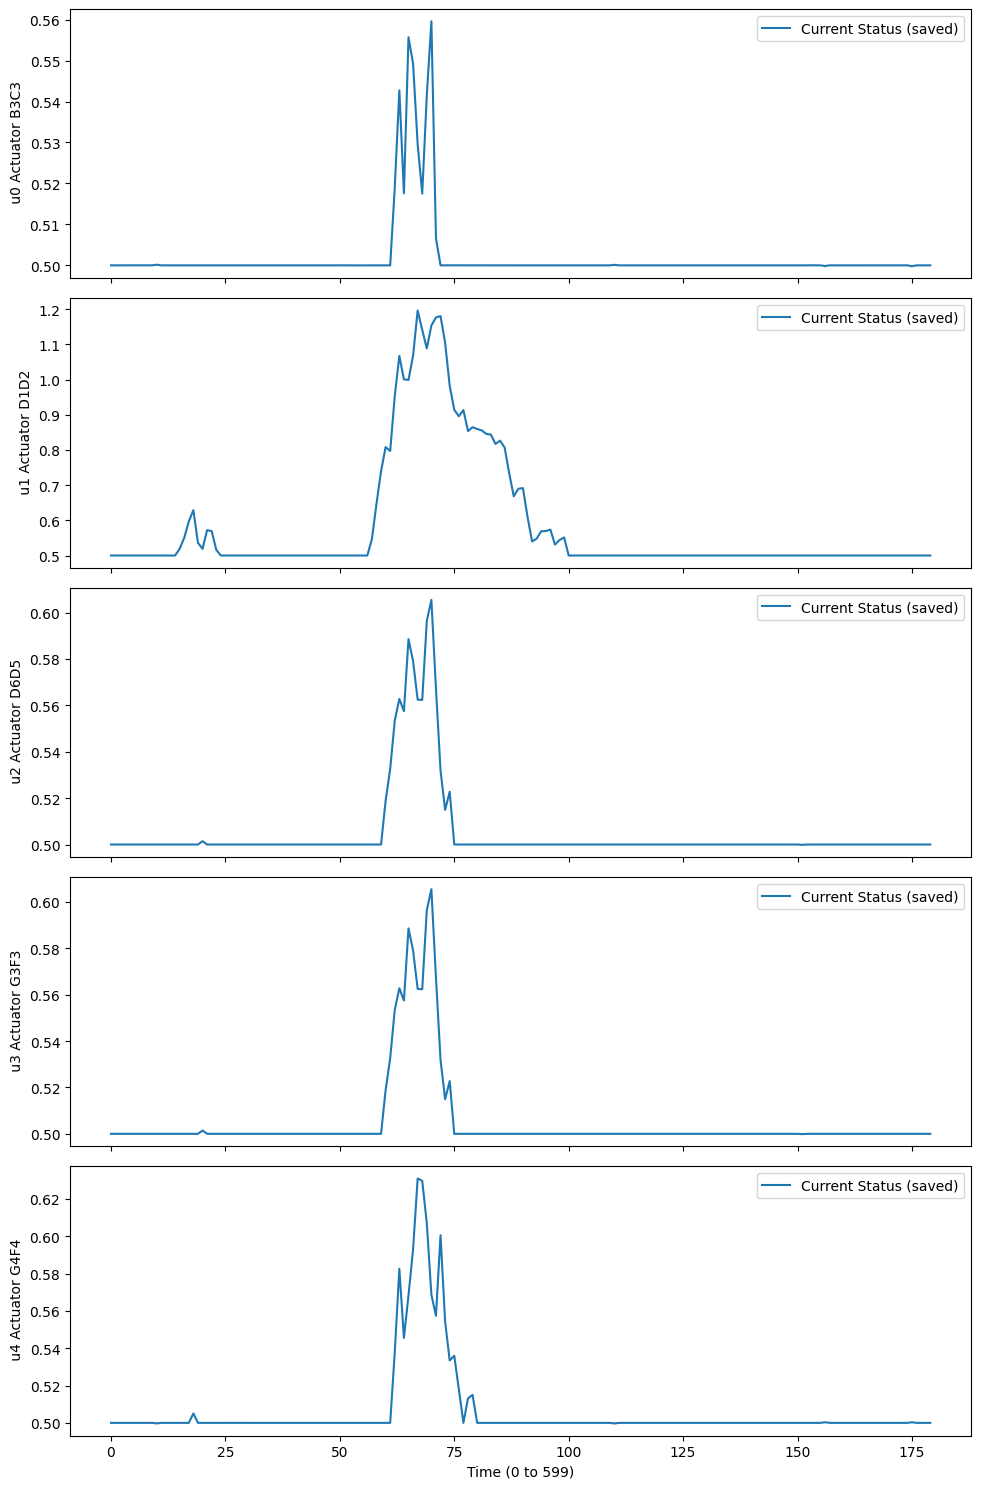

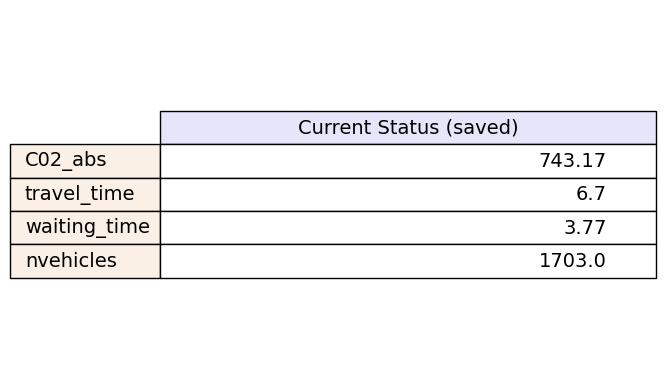

In [21]:
region = "Region 4"
com = Comparison(
    [experiment],  # type:ignore
    ["Current Status (saved)"],  # type:ignore
    region=region,
)
com.plot_density()
com.plot_flow()
com.plot_input()
com.plot_metrics()


## Printing and Ploting Utils

In [ ]:
def plot_results(result_path):
    region = "Region 4"
    print(f"plot {result_path} for region {region}")

    experiment = Experiment()
    experiment.load(result_path)
    com = Comparison([experiment], ["Current Status (saved)"], region=region)  # type:ignore
    
    com.plot_density()
    com.plot_flow()
    com.plot_input()
    com.plot_metrics()

### Compare and plot from CSV

In [ ]:
# Experiments need to be done and a custom setup of paths! (and polars)

BEST_RESULTS = [
    "q_star_final_S_500_K_60",
    "q_star_final_S_500_K_62",
    "q_star_final_S_470_K_60",
    "q_star_final_S_470_K_62",
    "q_star_final_S_600_K_60",
    "q_star_final_S_600_K_62",
]

def plot_best():
    flows = pl.DataFrame()
    densities = pl.DataFrame()
    for p in BEST_RESULTS:
        experiment = f"/home/silvan/coco/out/mpc/{p}"
        # density
        result_type = "density_results.csv"
        result_path = f"{experiment}/results/{result_type}"
        df = pl.read_csv(result_path)
        density = df.select(pl.nth(5)).rename(lambda column_name: p)  # type:ignore
        densities = densities.with_columns(density)
        # flow
        result_type = "flow_results.csv"
        result_path = f"{experiment}/results/{result_type}"
        df = pl.read_csv(result_path)
        flow = df.select(pl.nth(5)).rename(lambda column_name: p)  # type:ignore
        flows = flows.with_columns(flow)
    # density
    for col in densities.columns:
        plt.plot(np.arange(180), densities[col], label=col)
    plt.title("Density")
    plt.legend(BEST_RESULTS)
    plt.show()
    plt.close()
    # flow
    for col in flows.columns:
        plt.plot(np.arange(180), flows[col], label=col)
    plt.title("Flow")
    plt.legend(BEST_RESULTS)
    plt.show()
    plt.close()


In [28]:
import glob
import polars as pl
cfg = pl.Config()
cfg.set_tbl_rows(90)

def compare_mpc_results():
    summary = pl.DataFrame()
    for experiment in glob.glob("/home/silvan/coco/out/mpc/*"):
        experiment_name = experiment.split("/")[-1]

        # result_type = "density_prediction_results.csv"
        # result_type = "density_results.csv"
        # result_type = "error_results.csv"
        # result_type = "flow_results.csv"
        # result_type = "input_results.csv"
        result_type = "metrics.csv"

        result_path = f"{experiment}/results/{result_type}"

        df = pl.read_csv(result_path)

        if summary.shape[0] == 0:
            legend = df.select(pl.nth(0)).rename(lambda column_name: "Legend")  # type:ignore
            summary = summary.with_columns(legend)

        # use this for metrics
        result = df.select(pl.nth(1)).rename(lambda column_name: experiment_name)
        # use this for all others
        # result = df.select(pl.nth(5)).rename(lambda column_name: experiment_name)

        summary = summary.with_columns(result)

    legend = legend.to_series().to_list()
    statistic = summary.drop("Legend").transpose(
        include_header=True, column_names=legend
    )
    # debug or full list
    # print(summary)
    # print(statistic)

    # ## flow**.csv
    # stat = "Region 4"
    # print(f"stat: {stat}")
    # print(statistic.sort(stat))

    ## metrics.csv
    metrics = [
        "column",
        "travel_time",
        "waiting_time",
        # "C0_abs",
        "C02_abs",
        # "HC_abs",
        # "PMx_abs",
        # "NOx_abs",
        "fuel_abs",
        "nvehicles",
    ]
    for stat in metrics:
        print()
        print(f"stat: {stat}")
        print(statistic.select(metrics).sort(stat))
